### Notebook modelo de árbol de decisión y vecinos cercanos

En esta sesión nos concentraremos en la aplicación práctica de ambos modelos usando un pequeño conjunto de datos de habitabilidad de exoplanetas.

**Objetivos:**
- entrenar un **árbol de decisión** y un clasificador **kNN** con `scikit-learn`,
- interpretar predicciones y calcular `accuracy`,
- comparar ambos métodos en un mismo problema,
- entender por qué **kNN requiere escalamiento** de variables y los árboles no necesariamente.


(Adaptado de  Viviana Acquaviva (2023))



## Decision Trees

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


https://www.kaggle.com/code/willkoehrsen/visualize-a-decision-tree-w-python-scikit-learn

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd 


In [2]:
font = {'size'   : 20}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=20) 
matplotlib.rc('ytick', labelsize=20) 
matplotlib.rcParams['figure.dpi'] = 300

In [3]:
!pip install pydotplus
!pip install graphviz
from io import StringIO
from IPython.display import Image  
import pydotplus

from sklearn.tree import export_graphviz 

### Subconjunto de base de datos de Habitabilidad de planetas https://phl.upr.edu/projects/habitable-exoplanets-catalog

In [4]:
LearningSet = pd.read_csv('HPLearningSet.csv', index_col=0)

**Variables:**
- `S_MASS`: masa estelar ($M_\odot$)
- `P_PERIOD`: período orbital (días)
- `P_DISTANCE`: distancia planeta–estrella (AU)
- `P_HABITABLE`: clase objetivo (0 = no habitable, 1 = habitable)


In [5]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [6]:
print("Forma del dataset: ", LearningSet.shape)


Forma del dataset:  (18, 5)


### Haga una revisión rápida del set de datos
- Encuentre el tamaño del dataset, y las categorías de la variable `P_HABITABLE` y los ejemplos en cada categoría.
- También visualice la relación entre la masa, el periodo y la habitabilidad del planeta. Grafique el periodo en escala log

Forma del dataset: (18, 5)

Categorías de P_HABITABLE:
P_HABITABLE
0    10
1     8
Name: count, dtype: int64

Ejemplos por categoría:
0: Kepler-736 b, Kepler-636 b, Kepler-887 c, Kepler-772 b, K2-116 b, HD 68402 b, Kepler-445 c, HD 104067 b, GJ 4276 b, Kepler-63 b
1: Kepler-442 b, Teegarden's Star b, GJ 1061 c, Kepler-1544 b, Kepler-296 e, Kepler-705 b, Kepler-296 f, GJ 3293 d


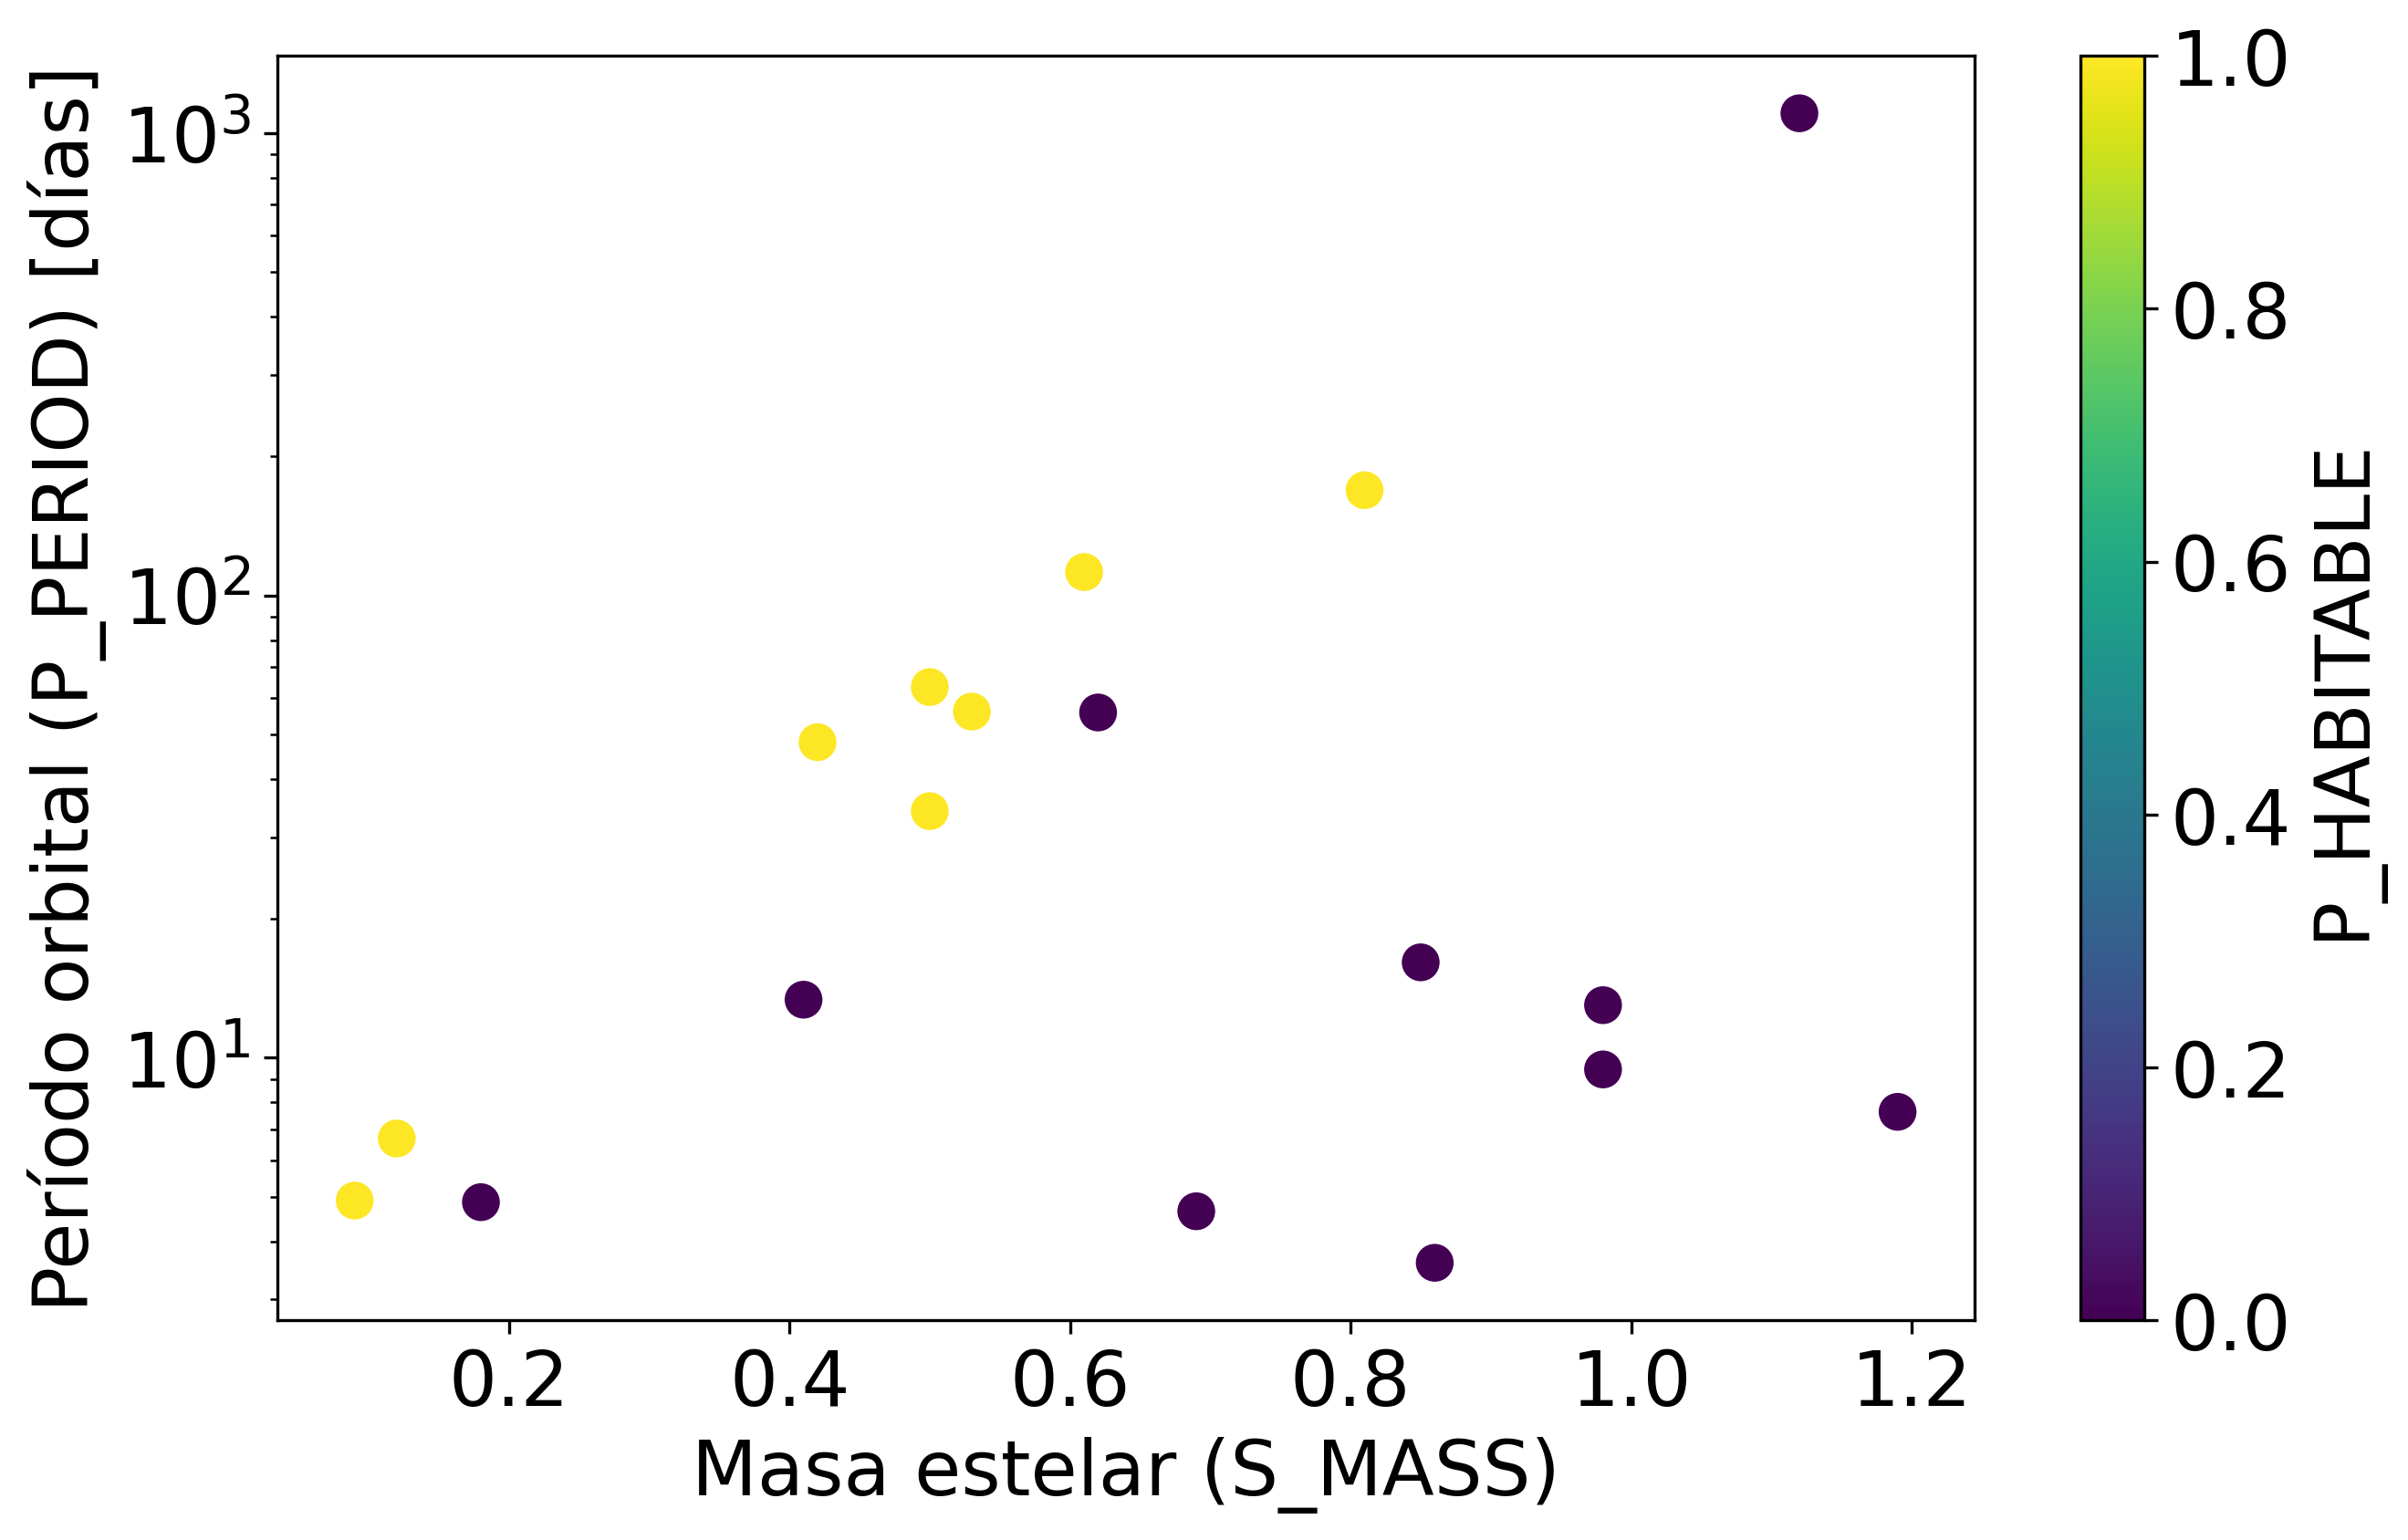

In [7]:
print("Forma del dataset:", LearningSet.shape)
print("\nCategorías de P_HABITABLE:")
print(LearningSet["P_HABITABLE"].value_counts().sort_index())

print("\nEjemplos por categoría:")
for clase in sorted(LearningSet["P_HABITABLE"].unique()):
    nombres = LearningSet.loc[LearningSet["P_HABITABLE"] == clase, "P_NAME"].tolist()
    print(f"{clase}: {', '.join(nombres)}")

plt.figure(figsize=(10, 6))
plt.scatter(
    LearningSet["S_MASS"],
    LearningSet["P_PERIOD"],
    c=LearningSet["P_HABITABLE"],
    cmap="viridis",
    s=80
)
plt.yscale("log")
plt.xlabel("Masa estelar (S_MASS)")
plt.ylabel("Período orbital (P_PERIOD) [días]")
plt.colorbar(label="P_HABITABLE")
plt.show()

**Antes de entrenar un modelo, te parece que las clases se separan fácilmente o no? Explique**


No parece que las clases se separen de forma totalmente clara. Hay una tendencia de que ciertos valores de masa y período están asociados con habitabilidad, pero también hay bastante solapamiento entre las clases, así que un algoritmo tendrá que aprender un límite de decisión más que una separación perfecta.

### Elijamos el set de entrenamiento y prueba

Para definir los sets de etrenamiento y prueba, haremos una división *manual*

Definimos que las primeras 13 filas del dataframe será el conjunto de entrenamiento y los últimos 5, el conjunto de prueba

> En un problema real, usualmente preferimos una división aleatoria o validación cruzada.


Usaremos .iloc para acceder a los índices del dataframe

In [8]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [9]:
TrainSet =  LearningSet.iloc[:13,:]  

TestSet = LearningSet.iloc[13:,:]

In [10]:
TrainSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [11]:
TestSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
13,HD 104067 b,0.62,55.80600,0.260000,0
14,GJ 4276 b,0.41,13.35200,0.087613,0
15,Kepler-296 f,0.50,63.33627,0.268885,1
16,Kepler-63 b,0.98,9.43415,0.088100,0
17,GJ 3293 d,0.42,48.13450,0.195336,1


También necesitamos definir para cada conjunto las características (features) y los objetivos (targets)

In [12]:
Xtrain = TrainSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features conjunto de entrenamiento

Xtest = TestSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features  conjunto de entrenamiento

In [13]:
Xtrain.columns

Index(['S_MASS', 'P_PERIOD', 'P_DISTANCE'], dtype='object')

In [14]:
ytrain = TrainSet.P_HABITABLE #target conjunto prueba

ytest = TestSet.P_HABITABLE  #target conjunto prueba

In [15]:
Xtest

,S_MASS,P_PERIOD,P_DISTANCE
13,0.62,55.80600,0.260000
14,0.41,13.35200,0.087613
15,0.50,63.33627,0.268885
16,0.98,9.43415,0.088100
17,0.42,48.13450,0.195336


In [16]:
ytrain

0     0
1     0
2     0
3     1
4     0
5     1
6     0
7     1
8     0
9     1
10    1
11    1
12    0
Name: P_HABITABLE, dtype: int64

### Entrenamos el modelo
Nota: En los árboles de decisión de scikit-learn, las características (o variables) se reorganizan aleatoriamente cada vez que se realiza una división para decidir cómo separar los datos. Esto significa que, incluso si se usa el mismo conjunto de datos de entrenamiento, la mejor forma de dividir los datos puede cambiar entre diferentes ejecuciones del modelo. Esta variación ocurre cuando varias divisiones posibles ofrecen la misma mejora en el criterio de evaluación (por ejemplo, reducir la impureza del nodo). En estos casos, el algoritmo puede elegir diferentes divisiones como "mejores" en diferentes ejecuciones debido al orden aleatorio en que se evalúan las características.

Para asegurar que los resultados del entrenamiento sean consistentes y reproducibles (es decir, que se obtenga el mismo árbol de decisión cada vez que se entrene con los mismos datos), es necesario fijar el parámetro random_state. Esto establece una semilla para el generador de números aleatorios utilizado por el algoritmo, garantizando que la permutación de las características sea la misma en cada ejecución y, por lo tanto, el resultado del modelo también sea el mismo.

In [17]:
from sklearn.tree import DecisionTreeClassifier #modelo de árbol de decisión


In [18]:
dt_model = DecisionTreeClassifier(random_state = 3) #Inicializamos el modelo con sus parámetros

dt_model.fit(Xtrain, ytrain) #En una línea, construimos el modelo

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,3
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Podemos visualizar el árbol (visualización "pro")

debe instalar la libreria [`pydotplus`](https://pypi.org/project/pydotplus/)  y [`graphviz`](https://pypi.org/project/graphviz/) 

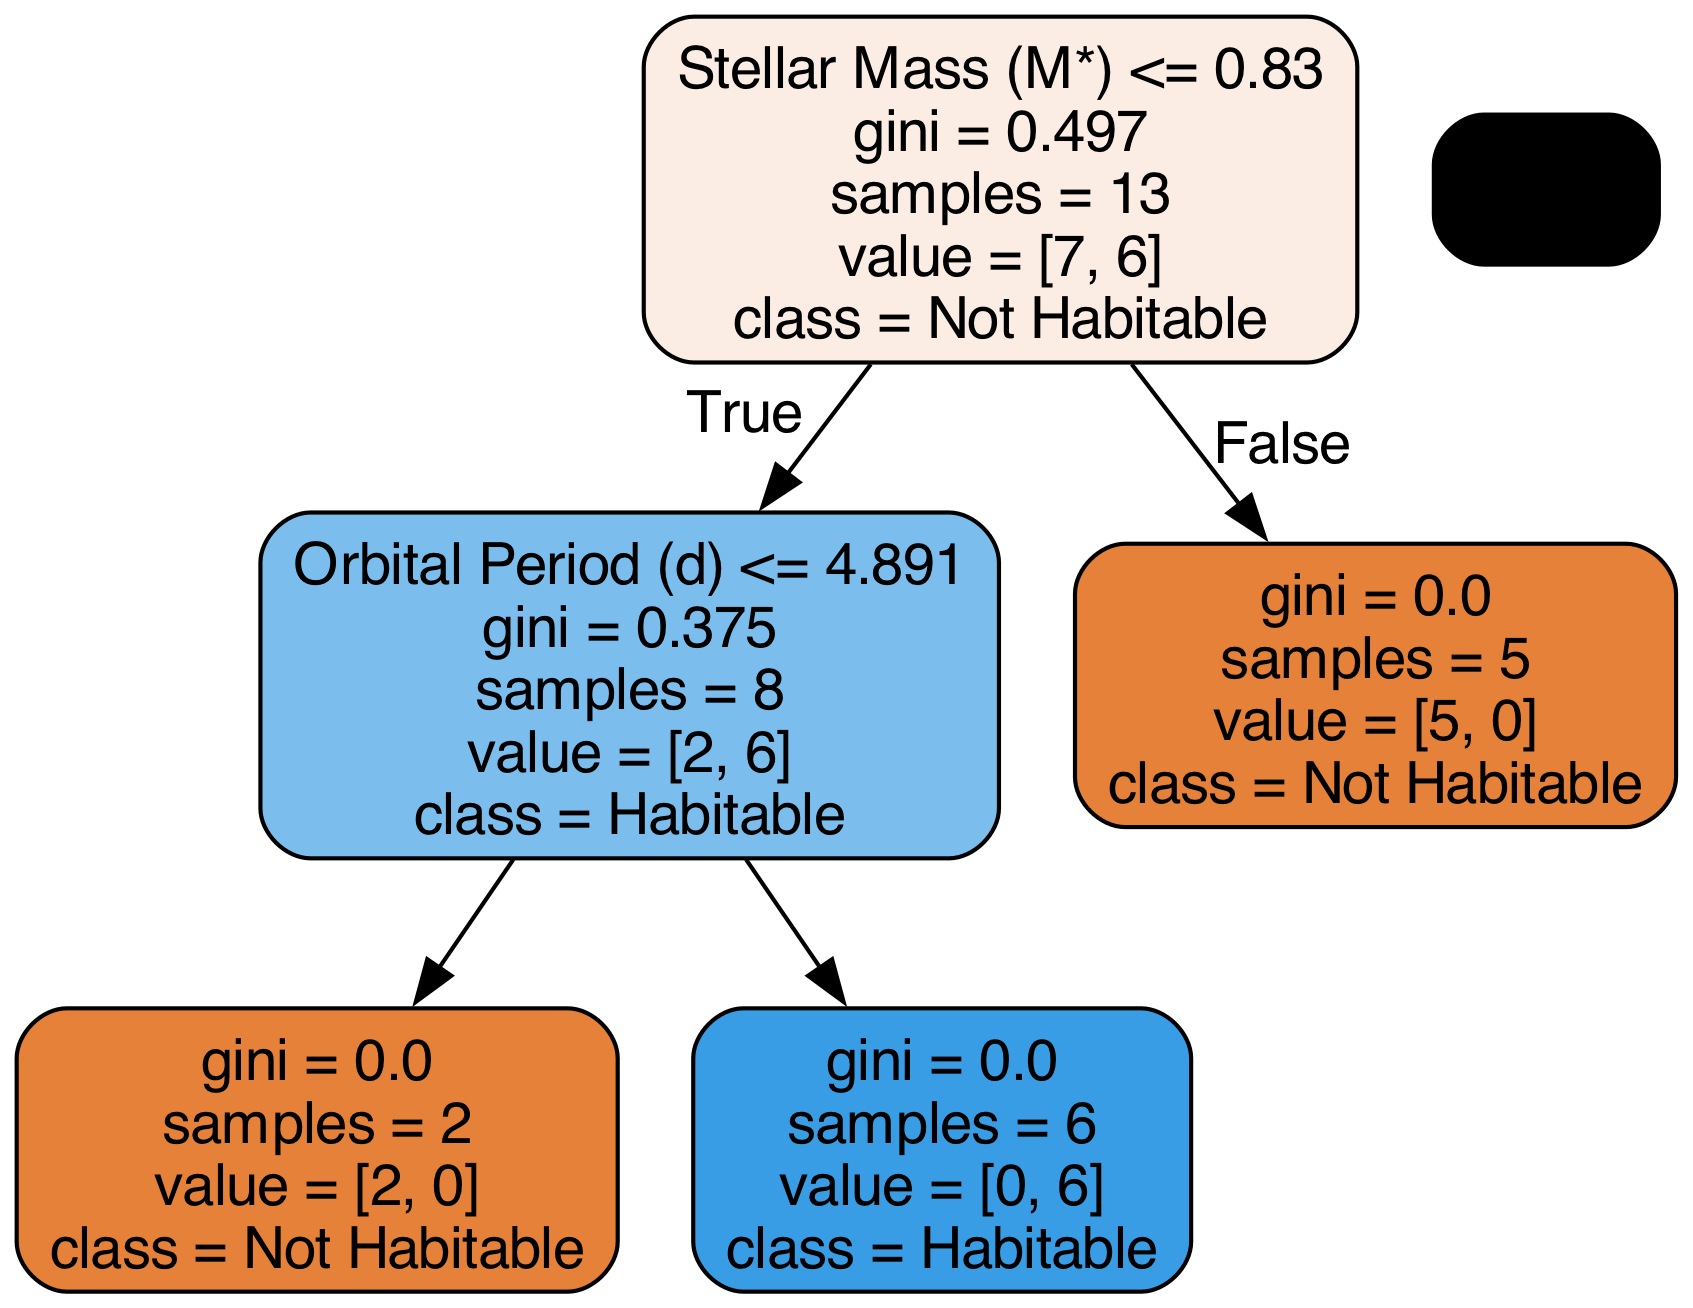

In [19]:
dot_data = StringIO()
export_graphviz(
    dt_model,
    out_file=dot_data,
    feature_names=['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
    class_names=['Not Habitable', 'Habitable'],
    filled=True,
    rounded=True
)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.set_dpi('300')
Image(graph.create_png())

### Visualización de sklearn

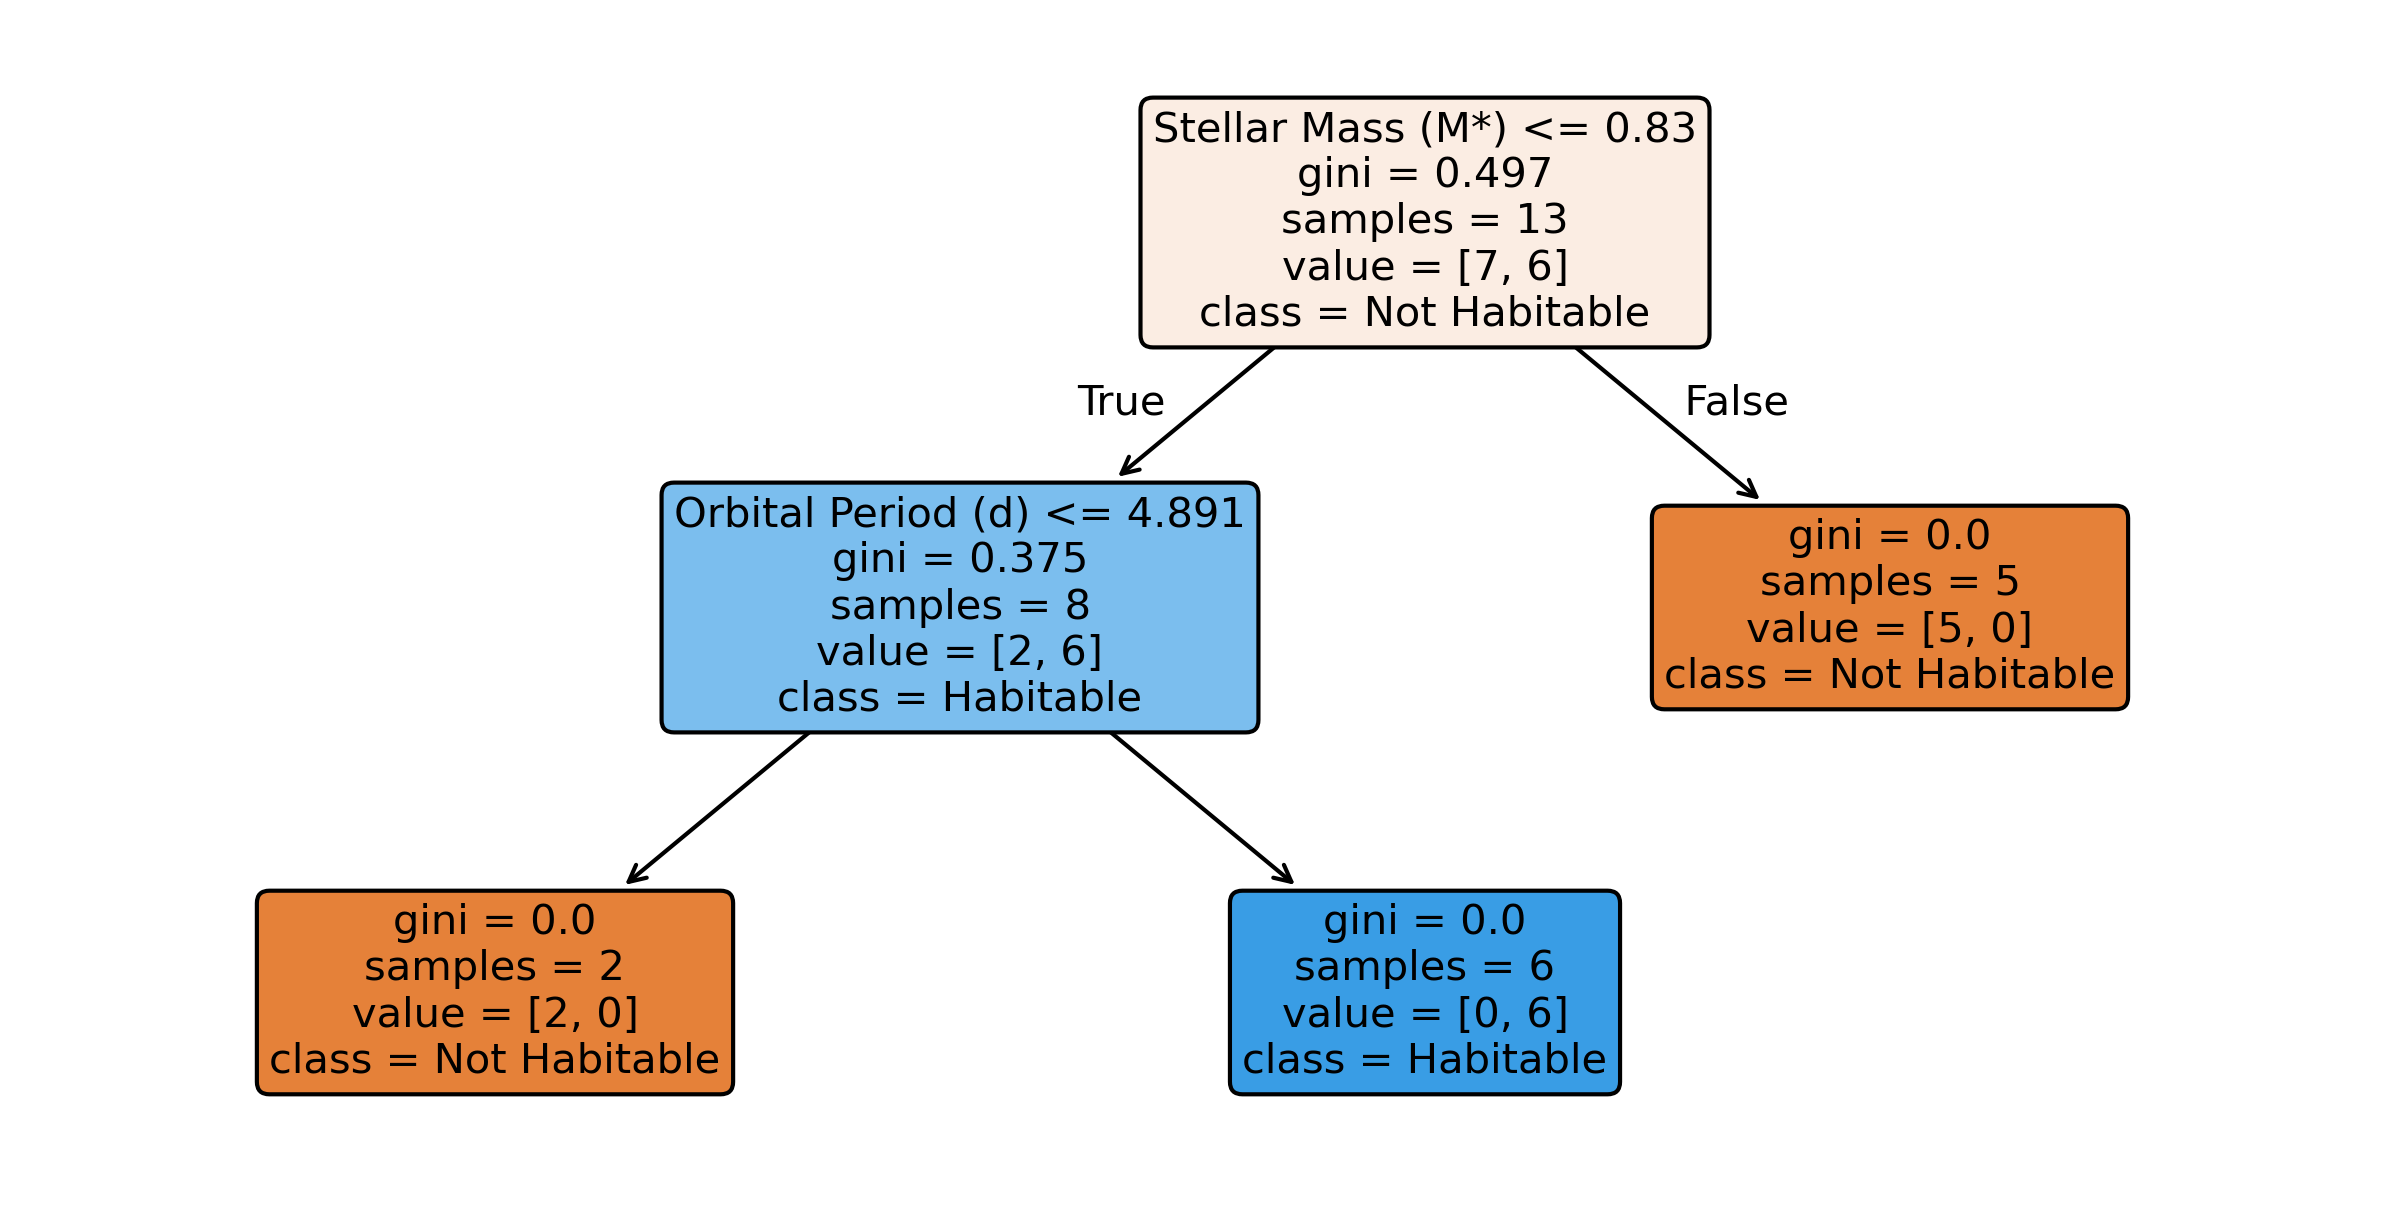

In [20]:
from sklearn import tree

plt.figure(figsize=(10,5))  # puede cambiar de acuerdo al tamaño del árbol
tree.plot_tree(dt_model,
               feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
               class_names = ['Not Habitable','Habitable'],
               filled=True,
               rounded=True,
               fontsize=10)

plt.show()

### También podemos visualizar las decisiones del clasificador. El color de sombreado predice la etiqueta, y el color de los puntos marca la etiqueta real:

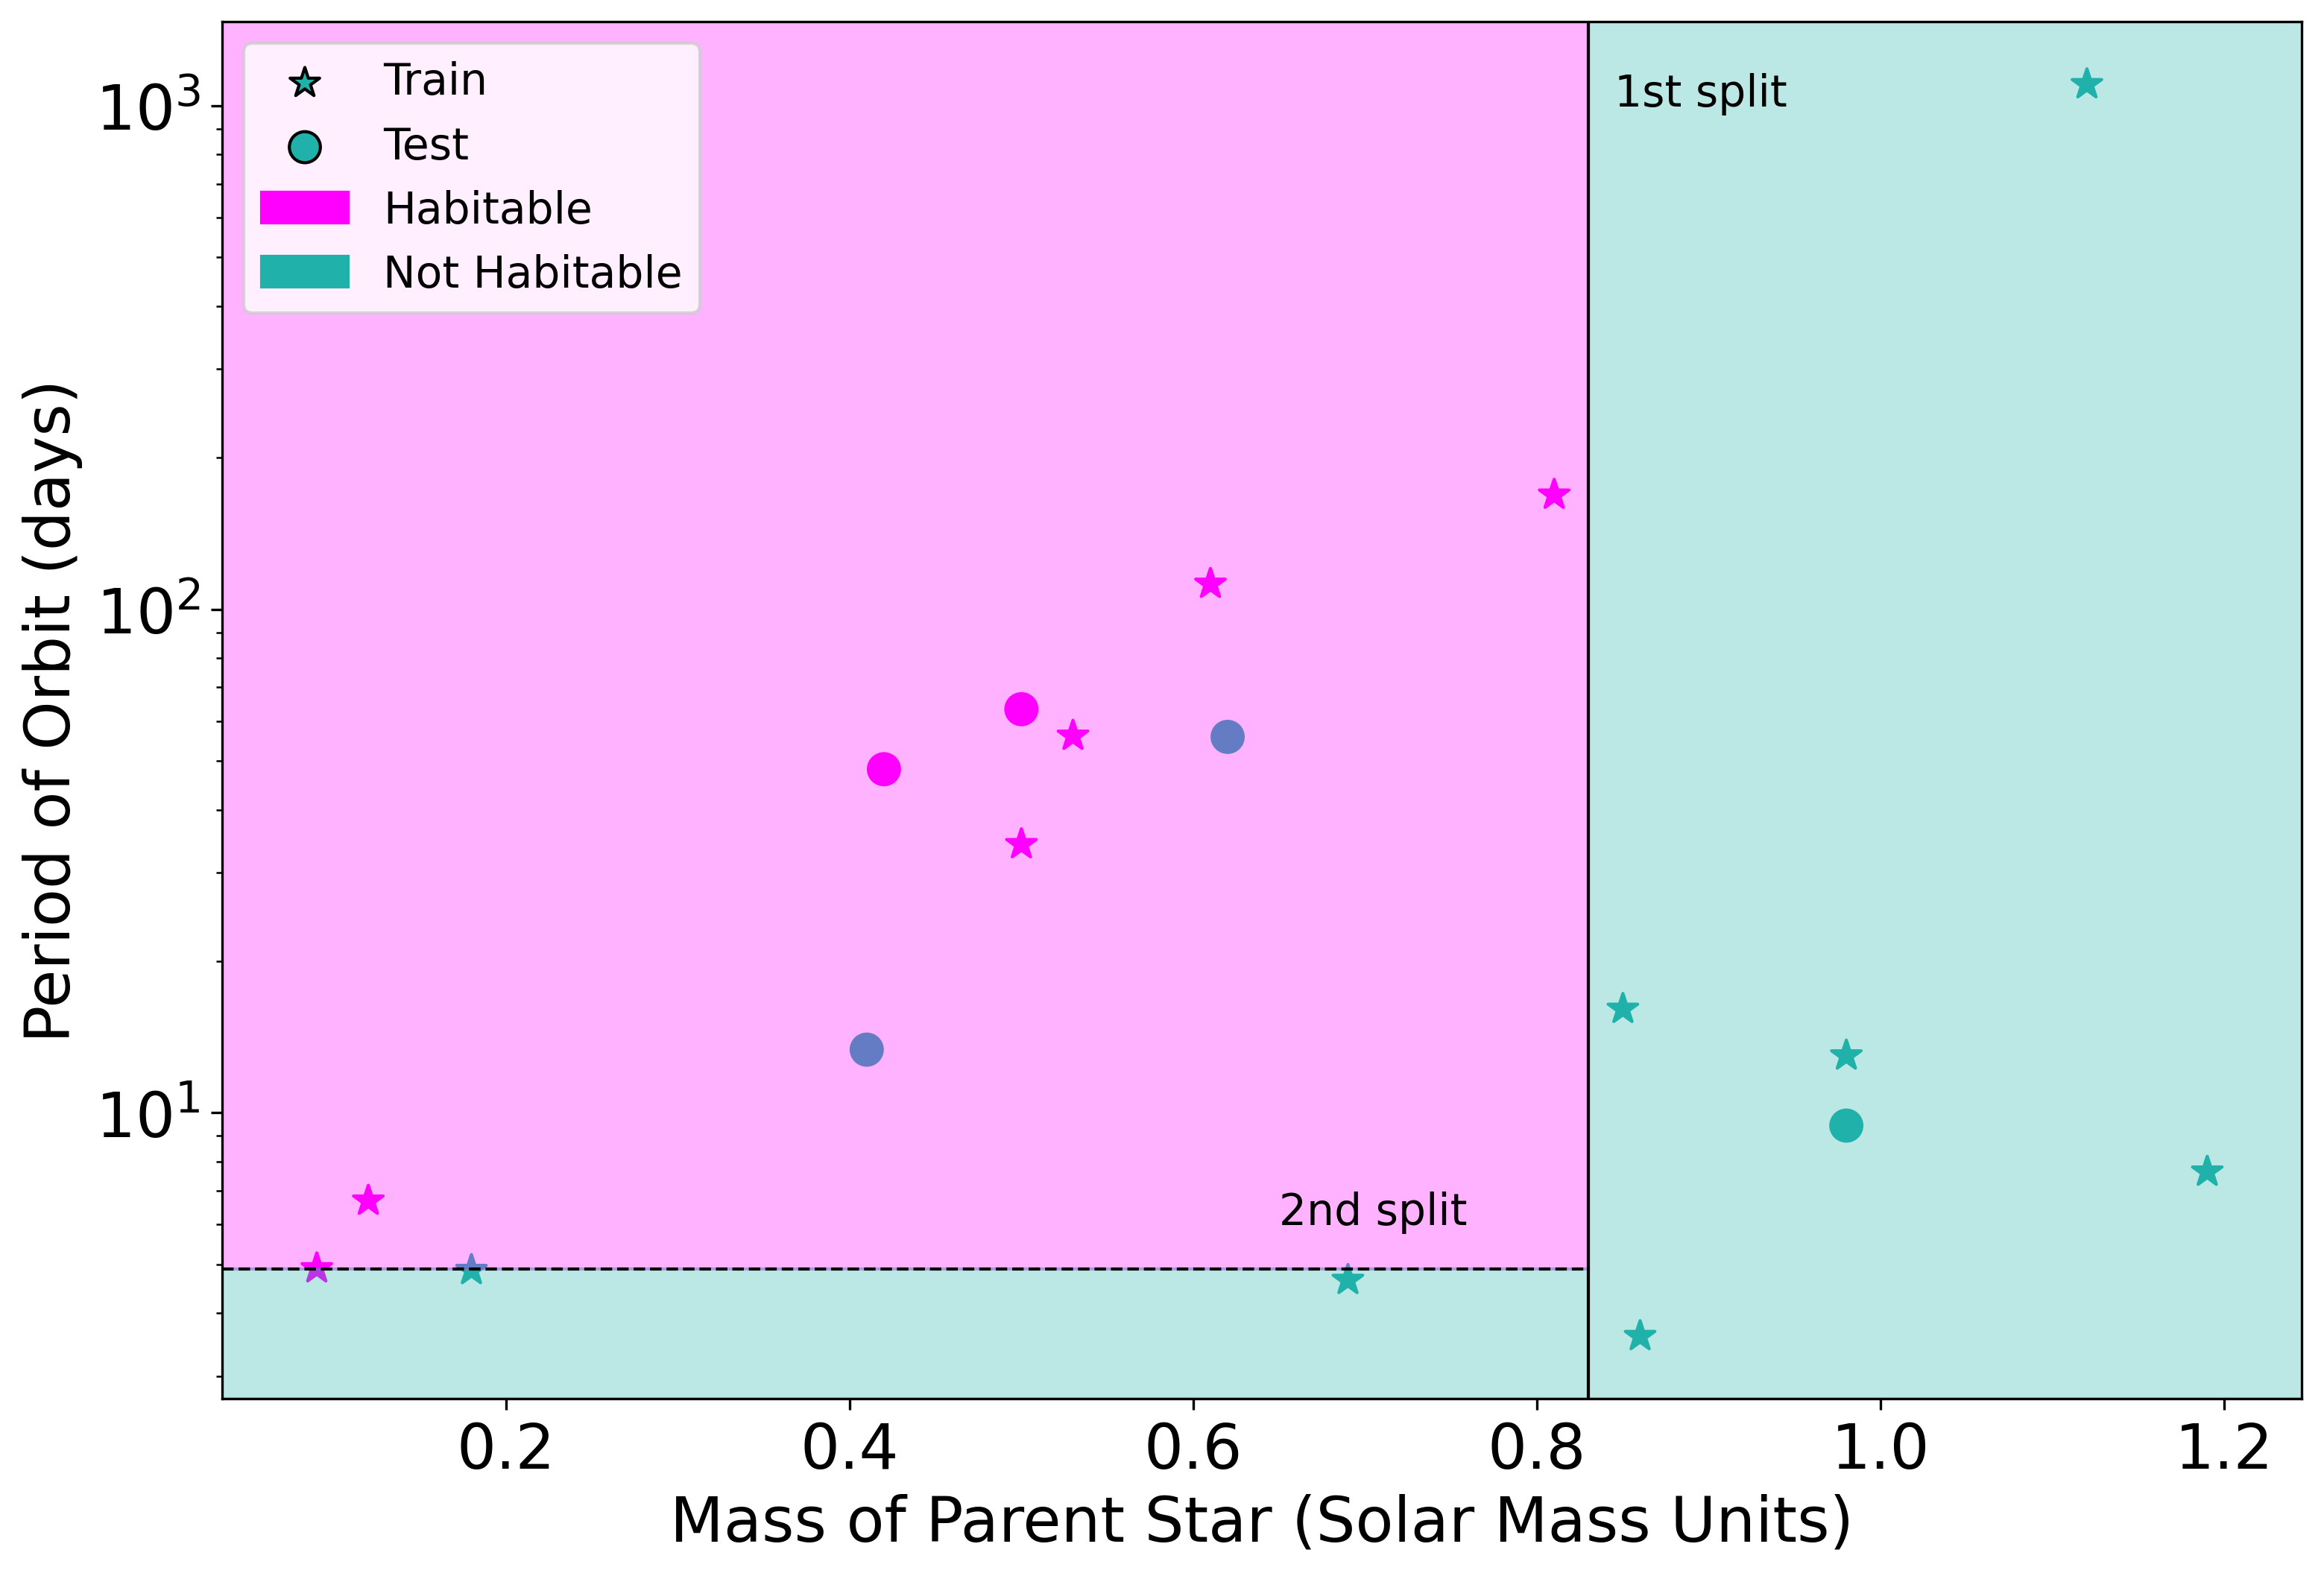

In [21]:
plt.figure(figsize=(12,8))

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

#puntos de entrenamiento y prueba

plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',\
            c = TrainSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Train')

plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',\
            c = TestSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Test')

plt.yscale('log')

plt.xlabel('Mass of Parent Star (Solar Mass Units)')

plt.ylabel('Period of Orbit (days)');

#splits del gráfico

plt.axvline(x=0.83, linewidth =1, ls = '-', label = '1st split', c='k')

plt.axhline(y=4.891, xmin = 0, xmax = 0.655, linewidth =1, ls = '--', label = '2nd split',c='k')

plt.text(0.845, 10**3, '1st split', fontsize=14)
         
plt.text(0.65, 6, '2nd split', fontsize=14)

#leyenda

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')

magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()

predhab = mpatches.Rectangle((0,4.891),0.83,ax.get_ylim()[1], 
                        fill = True,
                        color = '#FF00FF',
                        alpha = 0.3)

prednothab1 = mpatches.Rectangle((0.83,ax.get_ylim()[0]),ax.get_xlim()[1],ax.get_ylim()[1], 
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

prednothab2 = mpatches.Rectangle((0,ax.get_ylim()[0]),0.83,4.891-ax.get_ylim()[0], 
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')

plt.gca().add_patch(predhab)
plt.gca().add_patch(prednothab1)
plt.gca().add_patch(prednothab2)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14);


### Pregunta 
    
- ¿Cuál es el porcentaje de clasificaciones correctas en el set de entrenamiento?  Y en el set de prueba?


A este porcentaje de clasificaciones correctas lo llamaremos **accuracy**

### usando la métricas de sklearn, podemos encontrar el accuracy


In [22]:
import sklearn.metrics as metrics


In [23]:
ypred = dt_model.predict(Xtest) #generamos etiquetas de predicción en el set de prueba

In [24]:
ypred

array([1, 1, 1, 0, 1])

Accuracy es una métrica usual para evaluar modelos de clasificación, y hay una función en el módulo `sklearn.metrics`. Tenemos que comparar los resultados de la predicción `ypred` con los valores reales `ytest`

In [25]:
metrics.accuracy_score(ytest, ypred) #test score

0.6

también podemos encontrar el accuracy de los datos de entrenamiento, generando predicciones para los `Xtrain` y comparando con el `ytrain`

In [26]:
metrics.accuracy_score(ytrain, dt_model.predict(Xtrain)) #train score

1.0

**Respuesta a la pregunta anterior:**

- Accuracy en el set de entrenamiento: **100%**.
- Accuracy en el set de prueba: **60%** (3 de 5 objetos clasificados correctamente).

### Preguntas de interpretación
1. ¿El árbol clasifica perfectamente el conjunto de entrenamiento?
2. ¿Qué ocurre en el conjunto de prueba?
3. ¿Qué variable aparece en la raíz del árbol?
4. ¿Te parece que este árbol es simple o ya es relativamente profundo para un dataset tan pequeño?


**Respuestas**

1. Sí, el árbol clasifica correctamente el **100%** del conjunto de entrenamiento.
2. En el conjunto de prueba obtiene **60% de accuracy** (3 de 5 objetos).
3. La variable que aparece en la raíz es **`S_MASS`**.
4. Es un árbol relativamente simple: tiene pocas divisiones y una profundidad pequeña.

### Ahora elegiremos un set de entrenamiento distinto. Las 5 primeras filas serán de prueba y el resto será para el entrenamiento

In [27]:
# los primeros 5 de prueba, el resto de entrenamiento
TrainSet2 = LearningSet.iloc[5:,:] 

TestSet2 = LearningSet.iloc[:5,:]

### Repita el proceso anterior

1. Defina los dataframes de características y la serie de categorías para entrenamiento y prueba: `Xtrain2`, `Xtest2`, `ytrain2`, `ytest2`
2. inicialice el modelo de árbol de decisión para clasificación (defina semilla `random_state=3`
3. ajuste el modelo a los datos de entrenamiento
4. visualice el árbol
5. calcule accuracy para entrenamiento y prueba

In [28]:
Xtrain2 = TrainSet2.drop(['P_NAME', 'P_HABITABLE'], axis=1)
Xtest2 = TestSet2.drop(['P_NAME', 'P_HABITABLE'], axis=1)
ytrain2 = TrainSet2.P_HABITABLE
ytest2 = TestSet2.P_HABITABLE

dt_model2 = DecisionTreeClassifier(random_state=3)
dt_model2.fit(Xtrain2, ytrain2)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,3
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


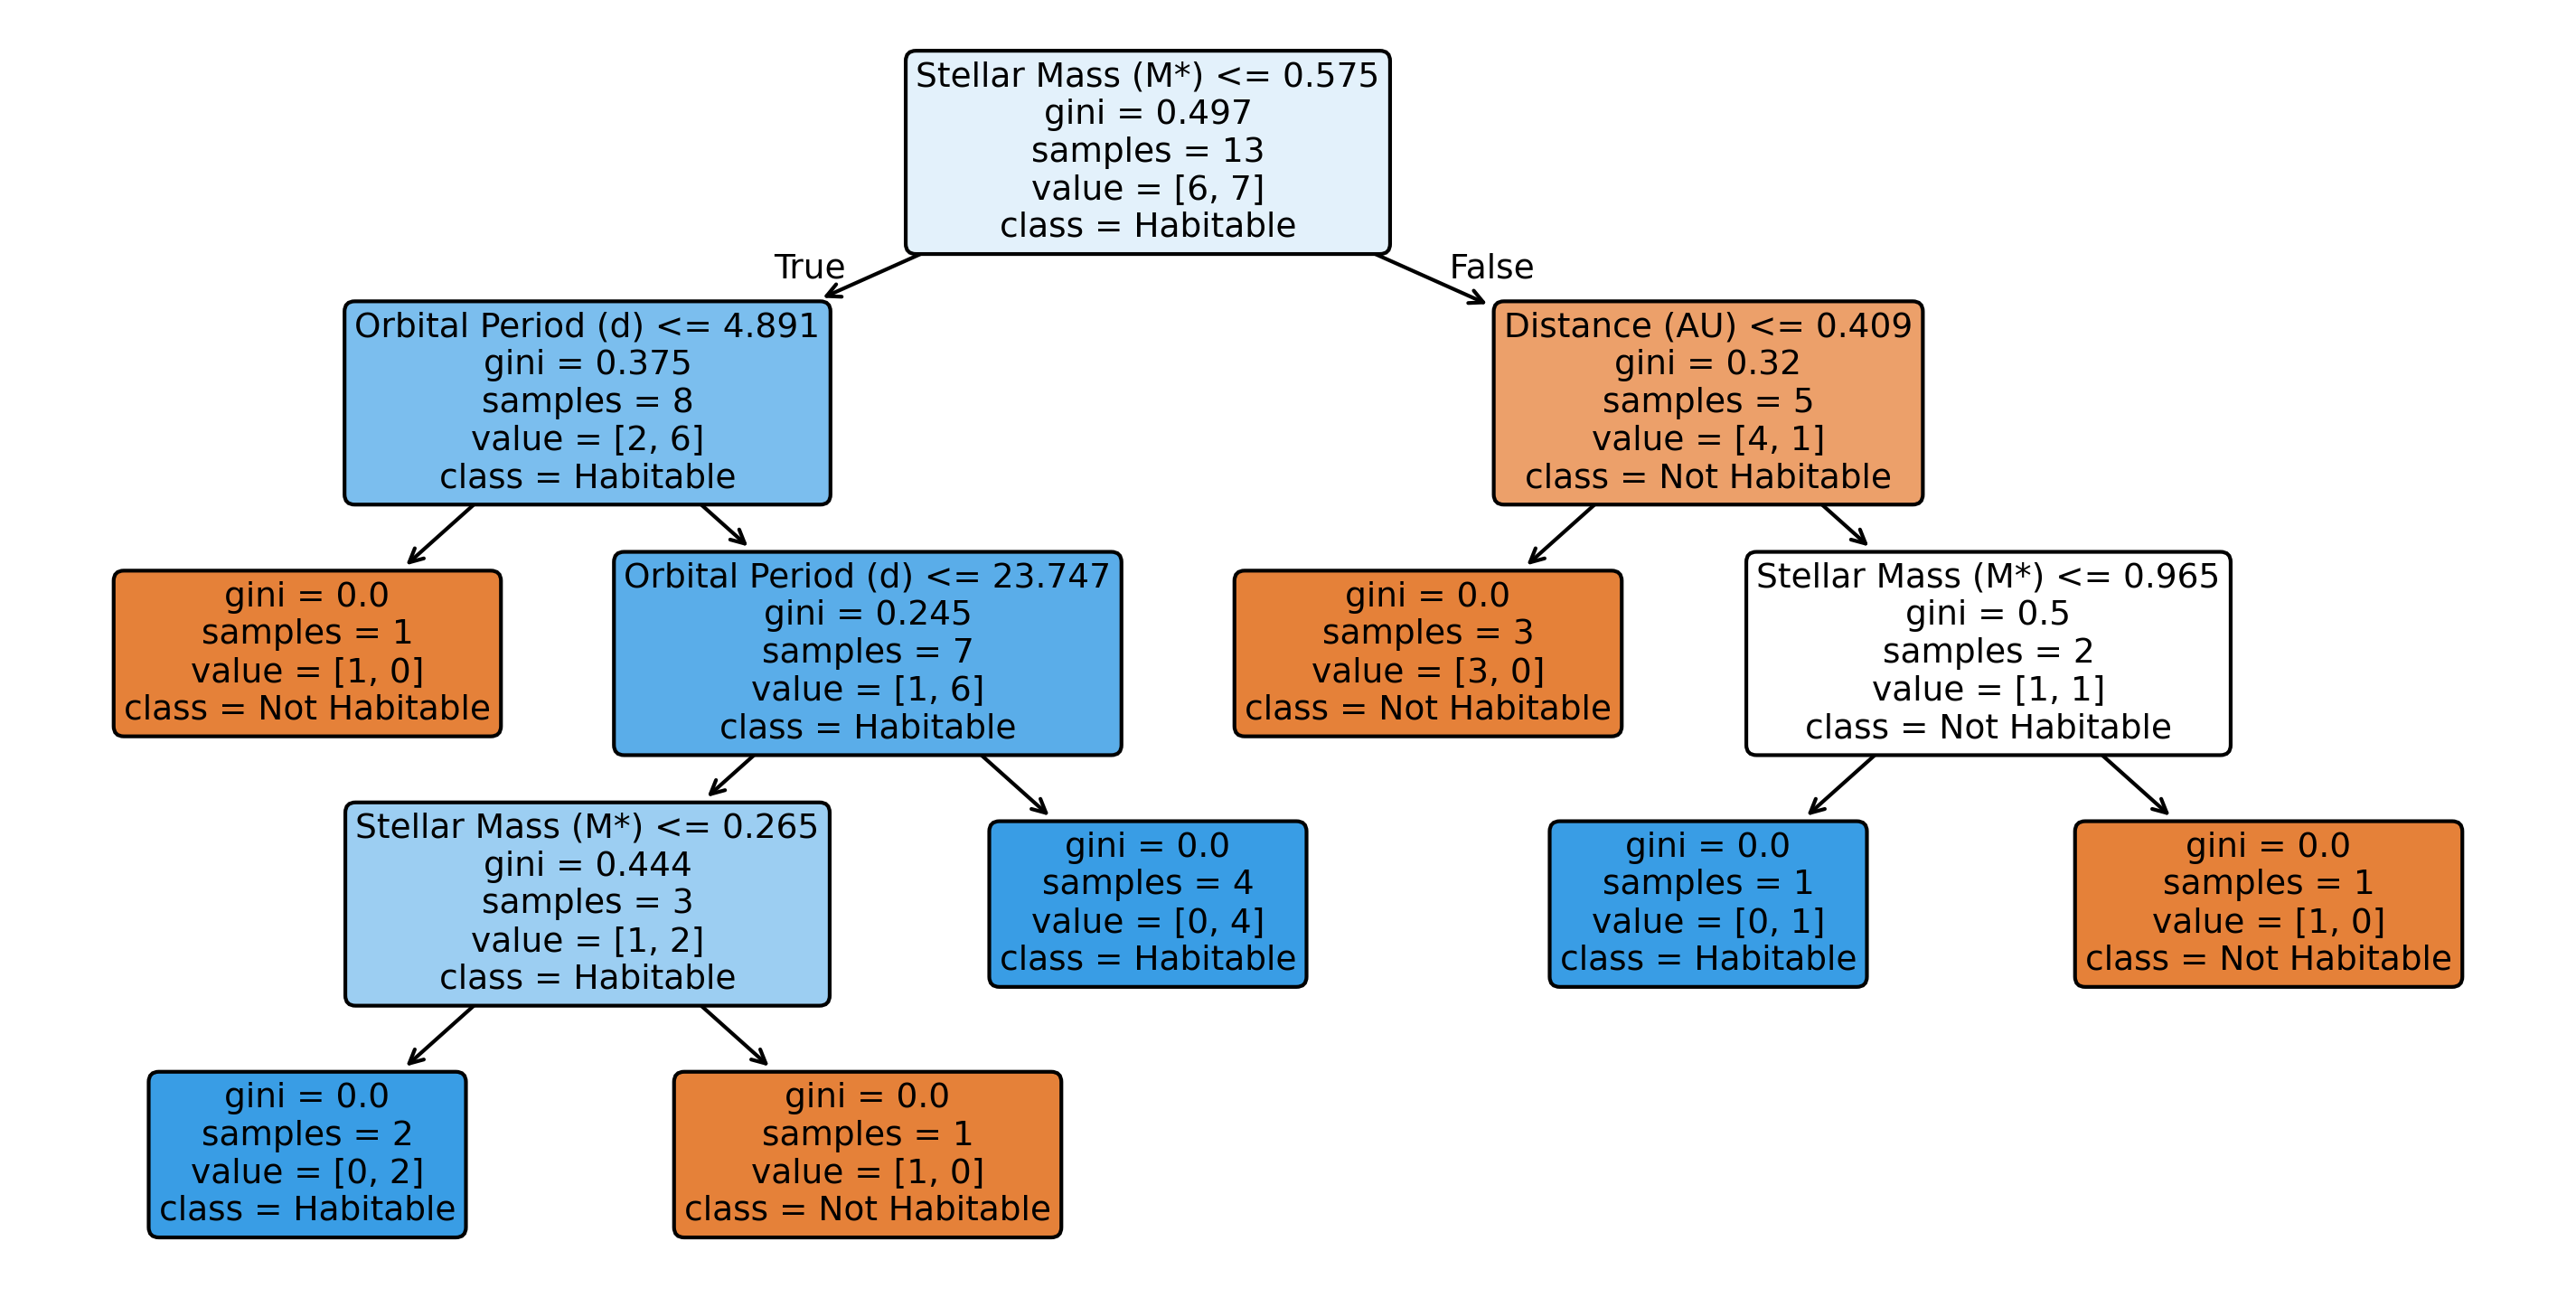

Accuracy entrenamiento: 1.0
Accuracy prueba: 1.0


In [29]:
plt.figure(figsize=(12, 6))
tree.plot_tree(
    dt_model2,
    feature_names=['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
    class_names=['Not Habitable', 'Habitable'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.show()

print("Accuracy entrenamiento:", metrics.accuracy_score(ytrain2, dt_model2.predict(Xtrain2)))
print("Accuracy prueba:", metrics.accuracy_score(ytest2, dt_model2.predict(Xtest2)))

### Preguntas:

- Compare el árbol de decisión inicial vs el obtenido ahora. Nota alguna diferencia?

- ¿Cuál es el accuracy (porcentaje de clasificaciones correctas) en el conjunto de entrenamiento? 

- ¿Y en el conjunto de prueba?

- Si ahora el resultado es mejor, ¿significa automáticamente que este árbol es “mejor” en general?


**Respuestas**

- El segundo árbol es más profundo y tiene más divisiones que el primero.
- Accuracy en entrenamiento: **100%**.
- Accuracy en prueba: **100%**.
- No. Un mejor resultado en este conjunto de prueba no significa automáticamente que el modelo sea mejor en general, especialmente porque el dataset es muy pequeño.

### Conclusiones

- Que puede concluir respecto a al ejercicio?

- Cambian los resultados dependiendo del set de datos que utilizamos?

- ¿Sería la Tierra clasificada como habitable por alguno de estos árboles?

**Conclusiones**

- Los resultados cambian al modificar qué objetos quedan en entrenamiento y prueba.
- Por lo tanto, la elección del conjunto de datos puede cambiar tanto la estructura del árbol como su accuracy.
- Usando aproximadamente `S_MASS = 1`, `P_PERIOD = 365.25` y `P_DISTANCE = 1` para la Tierra, **ambos árboles la clasifican como no habitable**. Esto muestra las limitaciones de trabajar con un conjunto de datos tan pequeño.

## k-Nearest Neighbors 

Aplicaremos ahora kNN al mismo problema.

>kNN clasifica según las etiquetas de los `k` vecinos más cercanos, es un método basado en distancia, por eso la **escala** de las variables sí importa.




In [30]:
from sklearn import neighbors 
import sklearn

Para el mismo set de datos de habitabilidad de planetas

In [31]:
Xtrain

,S_MASS,P_PERIOD,P_DISTANCE
0,0.86,3.601472,0.043718
1,0.85,16.080661,0.118082
2,1.19,7.638460,0.080420
3,0.61,112.305300,0.409327
4,0.98,12.992073,0.107408
5,0.09,4.910000,0.025200
6,0.69,4.655411,0.048086
7,0.12,6.689000,0.035000
8,1.12,1103.000000,2.180981
9,0.81,168.811170,0.557107


### "Entrenamos" el modelo
Es un algoritmo sencillo basado en la idea de distancia: buscamos los k (un número entero) objetos que están más cerca del que queremos clasificar, y tomamos la votación de la mayoría entre las k clases de los k vecinos.

kNN es un algoritmo basado en instancias (también llamado **"lazy learning"**), sigue necesitando saber con qué datos va a comparar para hacer predicciones futuras. El método fit le dice al algoritmo con qué datos va a trabajar.

El método fit en kNN no ajusta parámetros del modelo como en otros algoritmos.
Simplemente almacena los datos de entrenamiento para su uso durante la predicción.
Durante la predicción, el algoritmo calcula las distancias entre el nuevo punto y los puntos de entrenamiento almacenados para encontrar los k vecinos más cercanos y decidir la clase del nuevo punto basado en una votación mayoritaria.
En esencia, el proceso de "ajuste" en kNN es solo la configuración de los datos de referencia para comparaciones futuras, no un ajuste de parámetros basado en optimización.









In [32]:
knn_model = neighbors.KNeighborsClassifier(n_neighbors=3) # elegimos los 3 vecinos más cercanos

In [33]:
knn_model

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


#### Para propósitos de visualización, usemos solo las dos primeras características para construir el modelo.

In [34]:
Xtrain.iloc[:,:2] 

,S_MASS,P_PERIOD
0,0.86,3.601472
1,0.85,16.080661
2,1.19,7.638460
3,0.61,112.305300
4,0.98,12.992073
5,0.09,4.910000
6,0.69,4.655411
7,0.12,6.689000
8,1.12,1103.000000
9,0.81,168.811170


#### Se construye el modelo aplicando el método .fit al conjunto de entrenamiento. Luego, predice las etiquetas para el conjunto de prueba.

In [35]:
knn_model.fit(Xtrain.iloc[:,:2], ytrain)
ytestpred = knn_model.predict(Xtest.iloc[:,:2])

In [36]:
ytestpred, ytest.values #comparacion

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

#### Calculando accuracy en los sets de entrenamiento y prueba

In [37]:
print(metrics.accuracy_score(ytrain, knn_model.predict(Xtrain.iloc[:,:2])))
print(metrics.accuracy_score(ytest, knn_model.predict(Xtest.iloc[:,:2])))

0.6923076923076923
0.8


#### Después de ajustar y la predicción, podemos ver los k neighbors que encontró el modelo en el conjunto de prueba

In [38]:
knn_model.kneighbors(Xtest.iloc[:,:2])

(array([[ 0.26575741, 21.66422235, 39.72600482],
        [ 0.67412717,  2.76390862,  5.76653597],
        [ 7.28027781, 29.19416   , 47.25690512],
        [ 1.807928  ,  2.87670841,  3.5579225 ],
        [ 7.9223177 , 13.99261869, 32.05672308]]),
 array([[11, 10,  1],
        [ 4,  1,  2],
        [11, 10,  1],
        [ 2,  7,  4],
        [11, 10,  1]]))

### Visualizando los resultados

USamos la distancia del tercer vecino como el radio del círculo que encierra vecinos


In [39]:
for i in range(len(TestSet)):
    print(knn_model.kneighbors(Xtest.iloc[:,:2])[0][i,2])

39.7260048163029
5.766535965914376
47.2569051246575
3.5579225
32.056723080157795


El siguiente código dibuja un círculo incluyendo a los 3 vecinos más cercanos para cada punto

### Nota: Para la aplicación real (no la visualización), debiéramos usar todas las features disponibles 

/var/folders/3t/09lllqh55rq_f2b2nk1fkt5c0000gn/T/ipykernel_39038/4165556388.py:5: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  a= plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'None',\
/var/folders/3t/09lllqh55rq_f2b2nk1fkt5c0000gn/T/ipykernel_39038/4165556388.py:11: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  a= plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolor = 'None',\


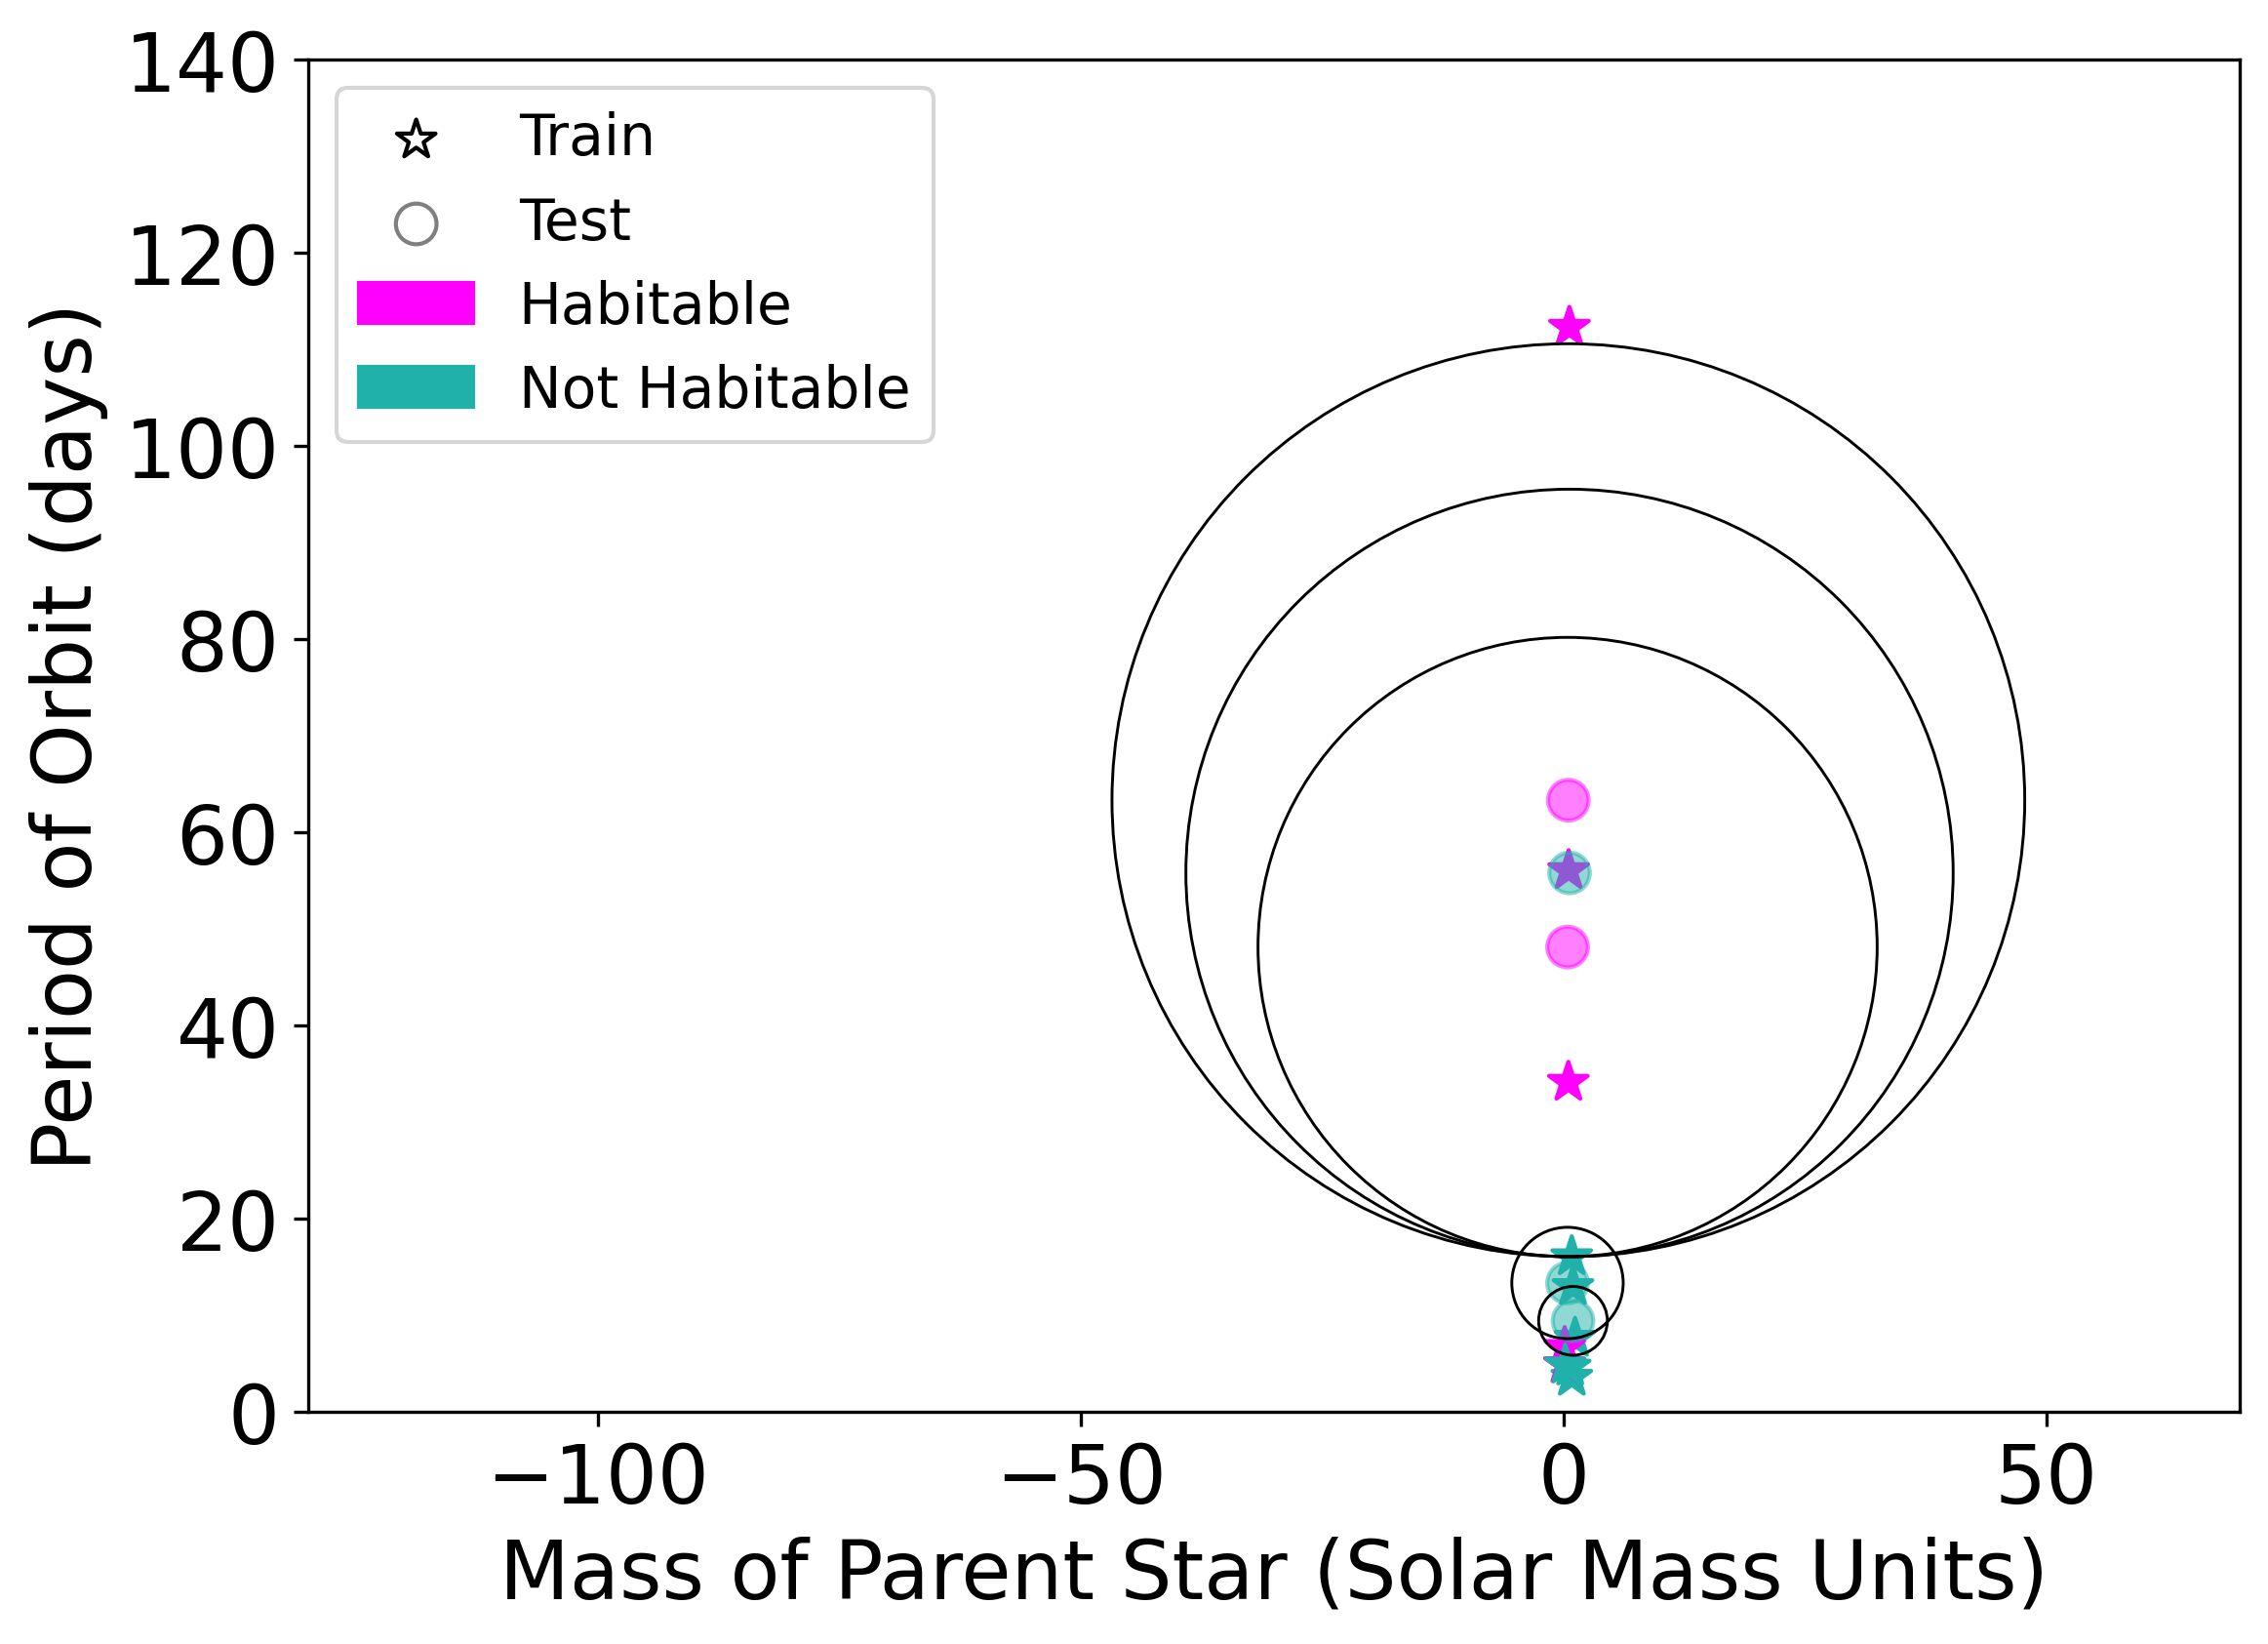

In [40]:
plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])


a= plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'None',\
            c = TrainSet['P_HABITABLE'], s = 100, label = 'Train', cmap=cmap) 

#a.set_facecolor('none')


a= plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolor = 'None',\
            c = TestSet['P_HABITABLE'], s = 100, label = 'Test', cmap=cmap, alpha=0.5) 

#a.set_facecolor('none')

for i in range(len(TestSet)): #plot neighbors

    circle1=plt.Circle((TestSet['S_MASS'].iloc[i],TestSet['P_PERIOD'].iloc[i]),knn_model.kneighbors(Xtest.iloc[:,:2])[0][i,2],\
                       lw = 0.7, edgecolor='k',facecolor='none')
    plt.gca().add_artist(circle1)
    
plt.gca().set_aspect(1)

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
leg.legend_handles[1].set_facecolor('none')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14)

plt.xlim(-130,70)
plt.ylim(0,140)
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)');

#plt.savefig('HabPlanetsKNN2features.png', dpi = 300)

### Nota algo particular en el gráfico?

Sí. Los círculos quedan muy deformados porque `S_MASS` y `P_PERIOD` tienen escalas muy distintas. Como kNN usa distancias, la variable con valores numéricos mayores domina el cálculo.

 **Si una dimensión tiene un rango mucho mayor que las otras, dominará el proceso de decisión. Este problema se puede solucionar mediante el <b>escalado</b>. El escalado es un paso de preprocesamiento muy importante para la mayoría de los algoritmos de aprendizaje automático.**



Algunos ejemplos de algoritmos de Scaler [aquí](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html).

Usaremos [`RobustScaler()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html), que se comporta mejor con outliers que la versión estándar, ya que escala de acuerdo a percentiles. Específicamente, usa la mediana (percentil 50) y el rango intercuartílico (IQR = Q3 - Q1), lo cual lo hace menos sensible a valores extremos


In [41]:
scaler = sklearn.preprocessing.RobustScaler() #inicializamos el Scaler

#### Importante!!

Debemos ajustar el escalador **sólo con los datos de entrenamiento**. Esto se hace porque **el modelo no debe tener acceso a los datos de prueba durante el entrenamiento**. Si usamos los datos de prueba para ajustar el escalador, estaríamos filtrando información del futuro, lo que se conoce como data leakage.

Esto puede llevar a dos problemas: por un lado, el modelo podría parecer más preciso de lo que realmente es, y por otro, podría aprender patrones que no se generalizan bien a datos nuevos, lo que se traduce en sobreajuste.

Para evitar esto, primero se ajusta el escalador con los datos de entrenamiento (`fit`), y luego se usa ese mismo escalador para transformar tanto el entrenamiento como el test (`transform`).

In [42]:
scaler.fit(Xtrain) # importante: solo escalamos el set de entrenamiento

,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False


In [43]:
scaledXTrain = scaler.transform(Xtrain)

In [44]:
scaledXTrain

array([[ 0.47222222, -0.18360363, -0.33840183],
       [ 0.44444444,  0.06038761,  0.05671512],
       [ 1.38888889, -0.10467304, -0.14339694],
       [-0.22222222,  1.94175736,  1.60417741],
       [ 0.80555556,  0.        ,  0.        ],
       [-1.66666667, -0.15801948, -0.43679409],
       [ 0.        , -0.16299717, -0.31519247],
       [-1.58333333, -0.12323674, -0.38472405],
       [ 1.19444444, 21.311672  , 11.01745224],
       [ 0.33333333,  3.04655169,  2.38937206],
       [-0.52777778,  0.41352236,  0.3761471 ],
       [-0.44444444,  0.84198052,  0.66159817],
       [-1.41666667, -0.15877753, -0.40201197]])

In [45]:
scaledXtest = scaler.transform(Xtest) # 

In [46]:
scaler.inverse_transform #esto invierte el escalado si es necesario

<bound method RobustScaler.inverse_transform of RobustScaler()>

**Ahora, con los datos escalados, aplique el modelo de kNN inicializado anteriormente, genere las predicciones y genere la misma visualización que en el caso anterior**

In [47]:
knn_model.fit(scaledXTrain[:, :2], ytrain)
ytestpred_scaled = knn_model.predict(scaledXtest[:, :2])

print(ytestpred_scaled)
print(ytest.values)
print("Accuracy entrenamiento:", metrics.accuracy_score(ytrain, knn_model.predict(scaledXTrain[:, :2])))
print("Accuracy prueba:", metrics.accuracy_score(ytest, ytestpred_scaled))

[1 0 1 0 1]
[0 0 1 0 1]
Accuracy entrenamiento: 0.8461538461538461
Accuracy prueba: 0.8


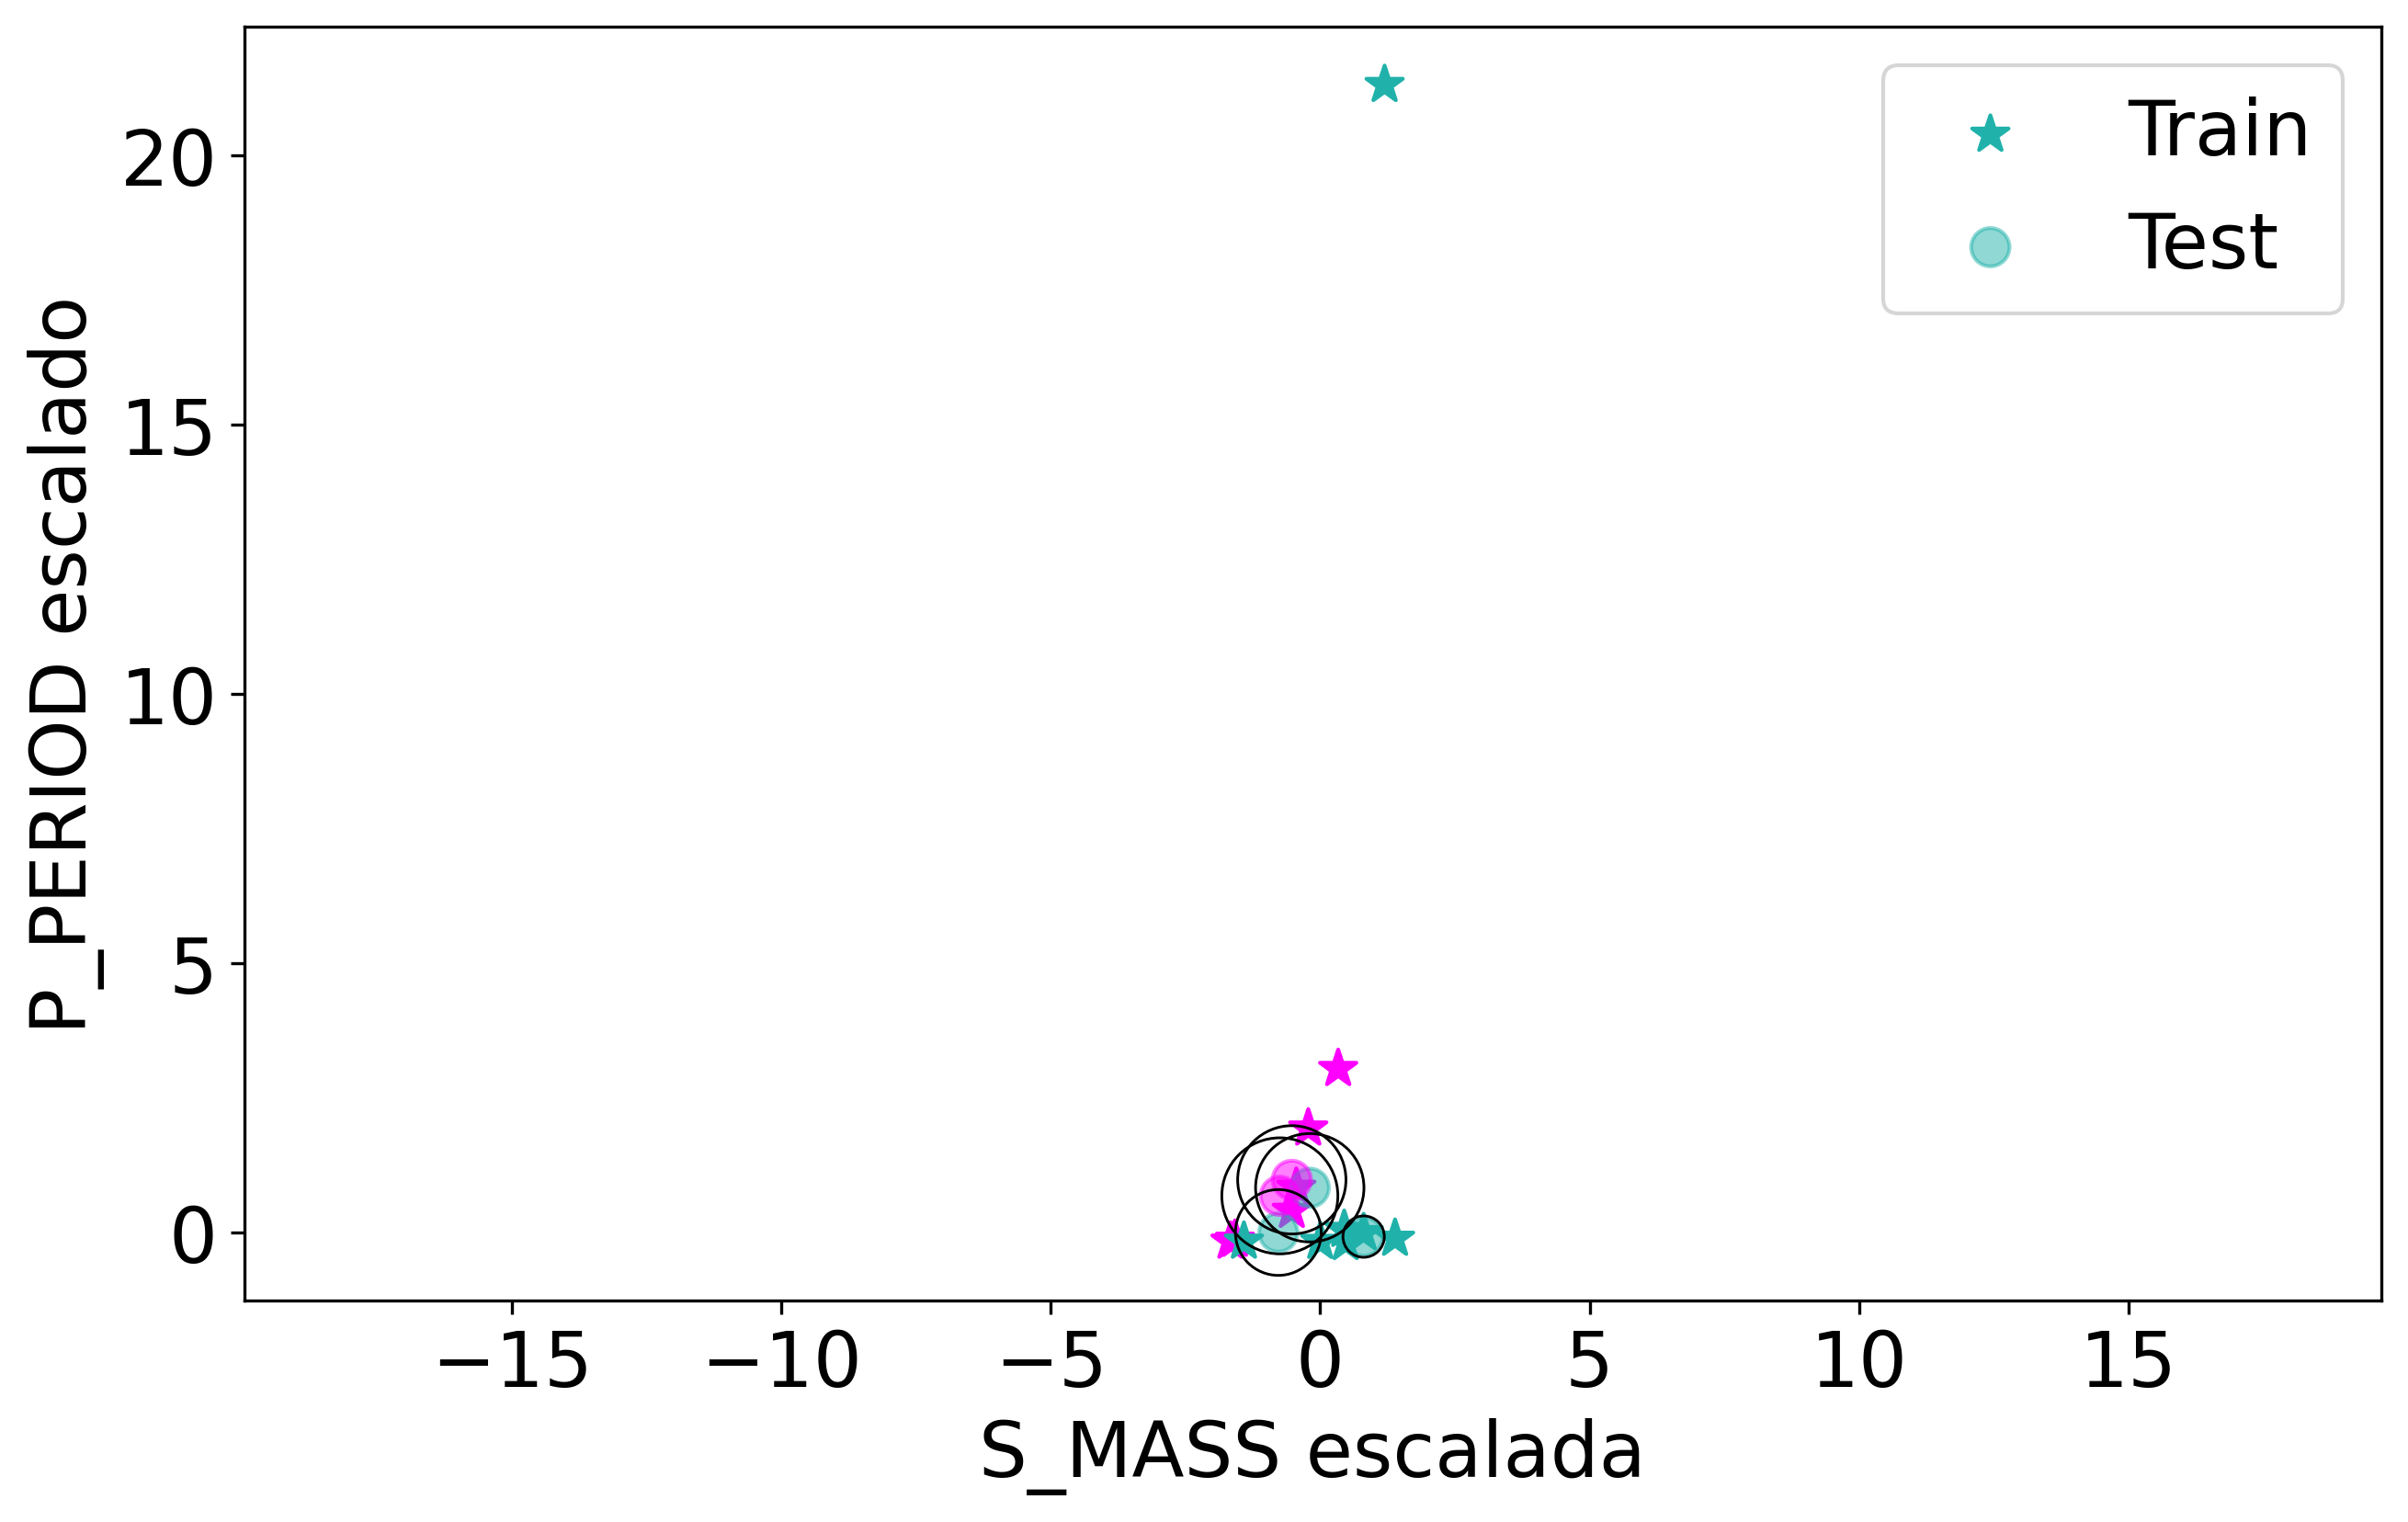

In [48]:
dist_scaled, _ = knn_model.kneighbors(scaledXtest[:, :2])

plt.figure(figsize=(10, 6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

plt.scatter(scaledXTrain[:,0], scaledXTrain[:,1], marker='*',
            c=ytrain, s=100, cmap=cmap, label='Train')
plt.scatter(scaledXtest[:,0], scaledXtest[:,1], marker='o',
            c=ytest, s=100, cmap=cmap, label='Test', alpha=0.5)

for i in range(len(TestSet)):
    circle = plt.Circle(
        (scaledXtest[i,0], scaledXtest[i,1]),
        dist_scaled[i,2],
        lw=0.7, edgecolor='k', facecolor='none'
    )
    plt.gca().add_artist(circle)

plt.gca().set_aspect('equal', adjustable='datalim')
plt.xlabel('S_MASS escalada')
plt.ylabel('P_PERIOD escalado')
plt.legend()
plt.show()

**Repita el proceso de kNN escalado, pero usando todas las caracteristicas, y compare el accuracy**

In [49]:
knn_all = neighbors.KNeighborsClassifier(n_neighbors=3)
knn_all.fit(scaledXTrain, ytrain)
ytestpred_all = knn_all.predict(scaledXtest)

In [50]:
acc_2 = metrics.accuracy_score(ytest, ytestpred_scaled)
acc_all = metrics.accuracy_score(ytest, ytestpred_all)

print("Accuracy con 2 características:", acc_2)
print("Accuracy con todas las características:", acc_all)

Accuracy con 2 características: 0.8
Accuracy con todas las características: 0.8


### Preguntas 

- Descubrimos que kNN necesita escalado ¿DT tiene el mismo problema?

- Compare las fortalezas y debilidades de DT y kNN

- ¿Qué diferencia conceptual hay entre cómo clasifica un árbol de decisión y cómo clasifica kNN?

- ¿Por qué el accuracy en entrenamiento no basta para evaluar un modelo?

- ¿Por qué kNN requiere escalamiento y un árbol de decisión no necesariamente?

- Si tuvieras que elegir uno de los dos métodos para este dataset pequeño, ¿cuál elegirías y por qué?


**1. ¿DT tiene el mismo problema de escalado que kNN?**

No. kNN usa distancias, por lo que la escala de las variables afecta directamente el resultado. Los árboles de decisión comparan cada variable con umbrales y no requieren escalado de la misma forma.

**2. Fortalezas y debilidades**

El árbol de decisión es fácil de interpretar y visualizar, pero puede sobreajustarse y cambiar bastante con pequeñas variaciones en los datos. kNN es simple y flexible, pero depende de la escala, de la elección de `k` y de la métrica de distancia.

**3. Diferencia conceptual**

El árbol clasifica mediante una secuencia de reglas y umbrales. kNN clasifica usando la clase mayoritaria entre los `k` ejemplos de entrenamiento más cercanos.

**4. ¿Por qué el accuracy de entrenamiento no basta?**

Porque mide el rendimiento sobre datos que el modelo ya vio. Un modelo puede ajustarse muy bien al entrenamiento y rendir peor con datos nuevos.

**5. ¿Por qué kNN requiere escalamiento y DT no necesariamente?**

Porque kNN calcula distancias entre variables. Si una variable tiene un rango mucho mayor, domina esa distancia. Un árbol evalúa cada característica por separado mediante umbrales.

**6. ¿Cuál elegiría para este dataset pequeño?**

Elegiría el árbol de decisión porque es más fácil de interpretar con tan pocos datos. De todas formas, los resultados deben tomarse con cautela porque el dataset es muy pequeño.